In [1]:
import numpy as np
import pandas as pd

In [6]:
embeddings_dir = "/home/earkfeld/Projects/MitoSpace4D/runs/20260111_kinetics-all-60frames_embeddings_resnet3d-kinetics-300eps_ablated-tmrm"

embeddings = np.load(f"{embeddings_dir}/embeddings_raw.npy")
img_paths = pd.read_csv(f"{embeddings_dir}/image_paths.csv", header=None)[0].tolist()
labels = np.load(f"{embeddings_dir}/labels.npy")
label_names = np.load(f"{embeddings_dir}/label_names.npy", allow_pickle=True)
metadata = pd.read_csv("/experiments/dhruv_4D_ResnetBiLSTM_phate/kinetics_metadata/phate_kinetics_metadata.csv")

In [13]:
metadata = metadata[metadata['path'].str.contains("-0.npy")]
metadata['label_name'] = ''
metadata['label_id'] = -1
metadata['embedding'] = None

In [14]:
metadata.head()

,sample id,region id,cell id,movie id,global_start_frame,path,label_name,label_id,embedding
0,20250722-2,0,0,0,0,20250722-2/000000-0.npy,,-1,None
3,20250722-2,0,1,0,0,20250722-2/000001-0.npy,,-1,None
6,20250722-2,0,2,0,0,20250722-2/000002-0.npy,,-1,None
9,20250722-2,0,3,0,0,20250722-2/000003-0.npy,,-1,None
12,20250722-2,0,4,0,0,20250722-2/000004-0.npy,,-1,None


In [15]:
for i, row in metadata.iterrows():
    base_path = row['path'].replace("-0.npy", "")
    matching_indices = [j for j, path in enumerate(img_paths) if base_path in path]
    if matching_indices:
        idx = matching_indices[0]
        metadata.at[i, 'label_name'] = label_names[labels[idx]]
        metadata.at[i, 'label_id'] = labels[idx]
        metadata.at[i, 'embedding'] = embeddings[idx]

In [17]:
# # Sampling single cells
# phate_data = []
# for lbl in np.unique(labels):
#     # pick a random set of embeddings from the dataframe with the given label
#     idx = metadata[metadata['label_id'] == lbl].sample(n=1).index[0]
#     embeddings = metadata.at[idx, 'embedding']
#     label_name = metadata.at[idx, 'label_name']
#     t_start = metadata.at[idx, 'global_start_frame']
#
#     for i in range(len(embeddings)):
#         t = t_start + i
#         phate_data.append({"drug": label_name, "time": float(t), "embedding": embeddings[i]})
#
# df_phate = pd.DataFrame(phate_data)
# df_phate.to_parquet("kinetics_3DMS_phate_single_cell.parquet", engine='pyarrow', index=False)

In [24]:
# Average per region per condition and stack regions for per-condition trajectories
phate_data = []

for lbl in np.unique(labels):
    df_condition = metadata[metadata['label_id'] == lbl].reset_index(drop=True)
    label_name = df_condition.at[0, 'label_name']
    regions = df_condition['region id'].unique()
    for region in regions:
        df_region = df_condition[df_condition['region id'] == region].reset_index(drop=True)
        embeddings = np.mean(np.stack(df_region['embedding'].to_list()), axis=0)

        t_start = df_region.at[0, 'global_start_frame']
        for i in range(len(embeddings)):
            t = t_start + i
            phate_data.append({"drug": label_name, "time": float(t), "embedding": embeddings[i]})

df_phate = pd.DataFrame(phate_data)

In [30]:
df_phate

,drug,time,embedding
0,control,0.0,"[-0.027503973, -0.023839979, -0.025441088, -0...."
1,control,1.0,"[-0.027178138, -0.02362319, -0.024930676, -0.0..."
2,control,2.0,"[-0.026953438, -0.023237461, -0.024471536, -0...."
3,control,3.0,"[-0.026551656, -0.022960266, -0.025405996, -0...."
4,control,4.0,"[-0.026100485, -0.023169057, -0.02555091, -0.0..."
...,...,...,...
11635,paraquat,475.0,"[-0.013546949, -0.013962938, -0.017053831, -0...."
11636,paraquat,476.0,"[-0.015914787, -0.011236043, -0.020887356, -0...."
11637,paraquat,477.0,"[-0.016571214, -0.01332116, -0.020752592, -0.0..."
11638,paraquat,478.0,"[-0.01805852, -0.014405847, -0.021778233, -0.0..."


In [25]:
df_phate.head()

,drug,time,embedding
0,control,0.0,"[-0.027503973, -0.023839979, -0.025441088, -0...."
1,control,1.0,"[-0.027178138, -0.02362319, -0.024930676, -0.0..."
2,control,2.0,"[-0.026953438, -0.023237461, -0.024471536, -0...."
3,control,3.0,"[-0.026551656, -0.022960266, -0.025405996, -0...."
4,control,4.0,"[-0.026100485, -0.023169057, -0.02555091, -0.0..."


In [26]:
# Save to parquet
df_phate.to_parquet("kinetics_3DMS_phate_mean-pooled.parquet", engine='pyarrow', index=False)

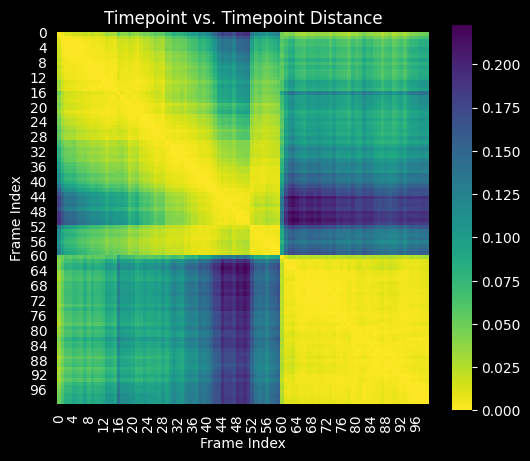

In [35]:
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns
embeddings = np.stack(df_phate['embedding'][:100])


dists = cdist(embeddings, embeddings, metric='cosine')

# 3. Plot
plt.figure(figsize=(6, 5))
sns.heatmap(dists, cmap='viridis_r', square=True)
plt.title("Timepoint vs. Timepoint Distance")
plt.xlabel("Frame Index")
plt.ylabel("Frame Index")
plt.show()